#**Problem**
Marketing A/B testing dataset
Marketing companies want to run successful campaigns, but the market is complex and several options can work. So normally they tun A/B tests, that is a randomized experimentation process wherein two or more versions of a variable (web page, page element, banner, etc.) are shown to different segments of people at the same time to determine which version leaves the maximum impact and drive business metrics.

The companies are interested in answering two questions:

Would the campaign be successful?
If the campaign was successful, how much of that success could be attributed to the ads?
With the second question in mind, we normally do an A/B test. The majority of the people will be exposed to ads (the experimental group). And a small portion of people (the control group) would instead see a Public Service Announcement (PSA) (or nothing) in the exact size and place the ad would normally be.

###**A/B_Testing:Bayesian Inference For Marketing Experimentation**

In [1]:
import pandas as pd
df=pd.read_csv('/content/marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


**DATA PROCESSING**

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [3]:
df.isnull().sum()

,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df=df.drop(['Unnamed: 0','user id'],axis=1)

In [6]:
df['converted']=df['converted'].astype(int)

In [7]:
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,0,130,Monday,20
1,ad,0,93,Tuesday,22
2,ad,0,21,Tuesday,18
3,ad,0,355,Tuesday,10
4,ad,0,276,Friday,14


**VISUALIZATION**

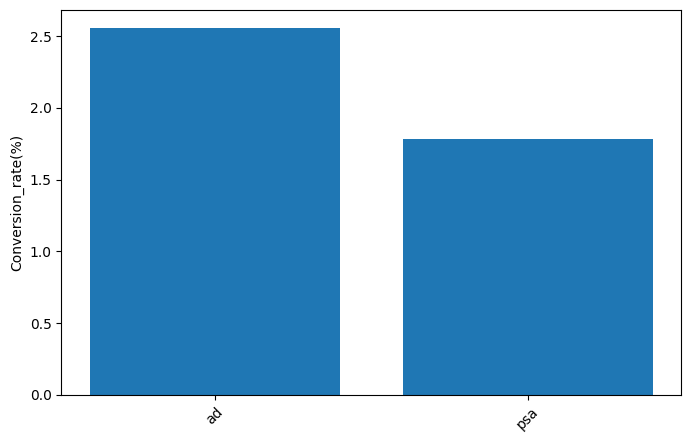

In [8]:
import matplotlib.pyplot as plt
cr_ad_psa=df.groupby('test group')['converted'].mean()*100
plt.figure(figsize=(8,5))
plt.bar(cr_ad_psa.index,cr_ad_psa.values)
plt.ylabel("Conversion_rate(%)")
plt.xticks(rotation=45)
plt.show()

We see the conversion rate of ad is higher than that of psa concluding showing ad contribute to the success of campaign more than that of psa

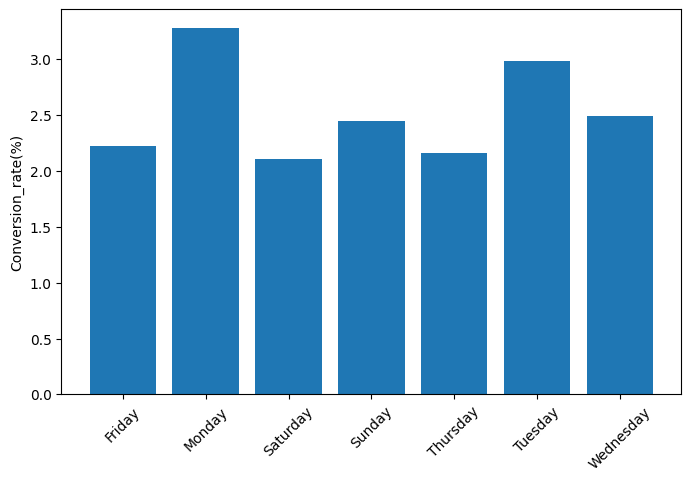

In [9]:
import matplotlib.pyplot as plt
#cr stands for conversion rate
cr_day=df.groupby('most ads day')['converted'].mean()*100
cr_hour=df.groupby('most ads hour')['converted'].mean()*100
plt.figure(figsize=(8,5))
plt.bar(cr_day.index,cr_day.values)
plt.ylabel("Conversion_rate(%)")
plt.xticks(rotation=45)
plt.show()

The chart shows the average conversion rate across differnt days of the week.Conversion rates vary moderately throughout the week , with Monday exhibiting highest conversion rate(3.2 %) followed by Tuesday (2.9%).Lowest conversion rates are observed on Saturday and Thursday (around 2.1%).
While weekdays such as Monday and Tuesday tend to perform better differnce across days are relatively small.Therefore although there appears to be slight increase in user responsiveness at beginning of week alone does not seem to be a dominant factor influencing conversions

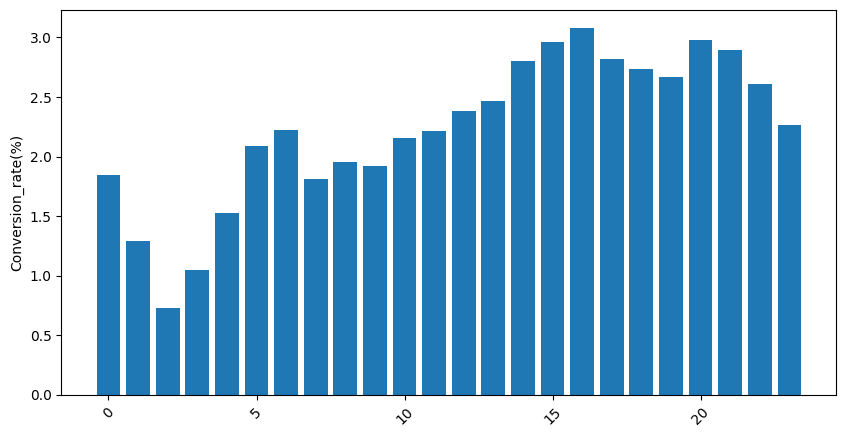

In [10]:
plt.figure(figsize=(10,5))
plt.bar(cr_hour.index,cr_hour.values)
plt.ylabel("Conversion_rate(%)")
plt.xticks(rotation=45)
plt.show()

Conversion rates are lowest during the early hous of the day (around 2-3 AM) where they fall below 1% indicating reduced user engagement during this period.As the day progresses conversion rates steadily increase reaching their peak between 3Pm and 4PM.

**BAYESIAN STATS**

In [11]:
ad = df[df['test group']=='ad']
psa = df[df['test group']=='psa']

ad_success = ad['converted'].sum()
ad_failure = len(ad) - ad_success

psa_success = psa['converted'].sum()
psa_failure = len(psa) - psa_success

**P-value Test**

In [12]:
from statsmodels.stats.proportion import proportions_ztest
count = [ad_success, psa_success]
nobs = [len(ad), len(psa)]

z_stat, p_value = proportions_ztest(count, nobs)

In [13]:
print(p_value)

1.7052807161559727e-13


In [14]:
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in conversion rates between the 'ad' and 'psa' groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in conversion rates between the 'ad' and 'psa' groups.")

Reject the null hypothesis: There is a significant difference in conversion rates between the 'ad' and 'psa' groups.


In [15]:
summary_table = pd.DataFrame({
    'Group': ['Ad', 'PSA'],
    'Successes': [ad_success, psa_success],
    'Failures': [ad_failure, psa_failure],
    'Total Users': [len(ad), len(psa)],
    'Conversion Rate (%)': [
        round((ad_success / len(ad)) * 100, 2),
        round((psa_success / len(psa)) * 100, 2)
    ]
})

print(summary_table)

  Group  Successes  Failures  Total Users  Conversion Rate (%)
0    Ad      14423    550154       564577                 2.55
1   PSA        420     23104        23524                 1.79


**A/B Testing using Beta-Binomial Model**

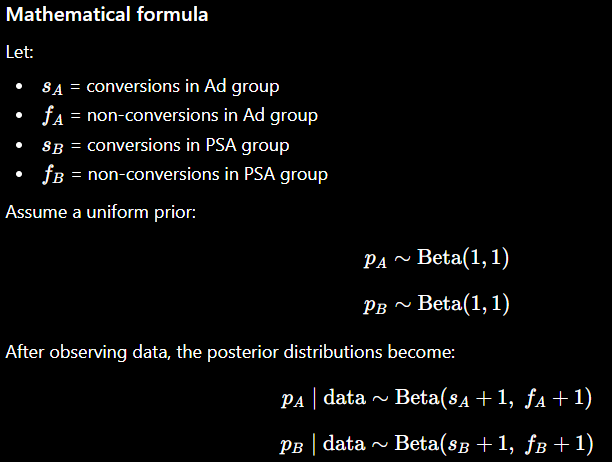

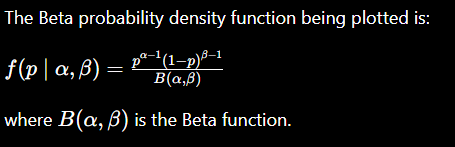

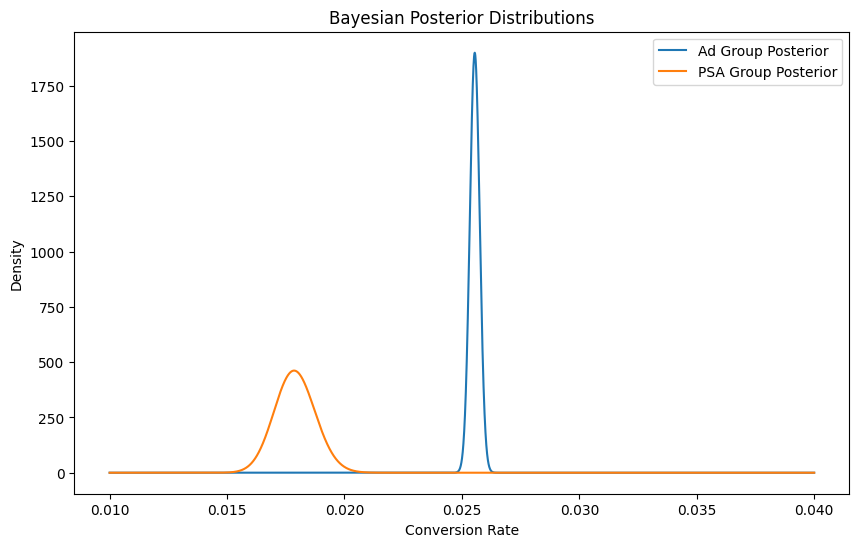

In [21]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# Posterior distributions
ad_alpha = ad_success + 1
ad_beta = ad_failure + 1

psa_alpha = psa_success + 1
psa_beta = psa_failure + 1

# Generate x values
x = np.linspace(0.01, 0.04, 10000)

# Compute beta distributions
ad_posterior = beta.pdf(x, ad_alpha, ad_beta)
psa_posterior = beta.pdf(x, psa_alpha, psa_beta)

# Plot
plt.figure(figsize=(10,6))

plt.plot(x, ad_posterior, label='Ad Group Posterior')
plt.plot(x, psa_posterior, label='PSA Group Posterior')

plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.title('Bayesian Posterior Distributions')

plt.legend()
plt.show()

The plot shows the posterior distributions of conversion rates for two groups — the Ad Group (blue) and the PSA Group (orange) — estimated using a Beta-Binomial Bayesian model. The Ad Group posterior is centered around ~0.025 (2.5%), while the PSA Group posterior is centered around ~0.018 (1.8%). Both distributions are very narrow (high density peaks), indicating high certainty in the estimates due to large sample sizes


Ad Group Wins — Ad conversion rate (2.5%) is higher than PSA (~1.8%).            
High Certainty — Narrow posteriors confirm large sample size with very little uncertainty.                                                                     
No Overlap — Distributions don't overlap, meaning P(Ad > PSA) ≈ 100%.

**Relative Lift=(CRad​−CRpsa​​)/CRpsa**

In [17]:
print('Uplift: ',(2.55-1.79)*100/1.79)

Uplift:  42.458100558659204


In [18]:
beta.ppf([0.025, 0.975], ad_alpha, ad_beta)

array([0.02513826, 0.0259614 ])

In [19]:
ad_samples = np.random.beta(ad_alpha, ad_beta, 100000)
psa_samples = np.random.beta(psa_alpha, psa_beta, 100000)

In [20]:
probability = (ad_samples > psa_samples).mean()

print(f"{probability:.6f}")

1.000000


The advertisement group achieved approximately 42% higher conversion rate compared to the PSA group, with posterior probability >99% that the ad performs better.